# Time Series Forecasting Runthrough

A short runthrough of Moving Average and the other forecasting methods, using Algeria's exports.

We cover:

1. **Moving average**, as a smoother
2. **Mean** and **Naive** forecasts, the two benchmarks
3. **Simple exponential smoothing (SES)**, which sits between the mean and the naive method

In the **Appendix**, we left **ARMA model** and evaluation methods (**MASE, AICc**) for reference.

**Data.** Algeria, exports of goods and services (% of GDP), yearly, 1960 to 2025.
Source: World Bank Group, World Development Indicators.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

OBS   = "#2b2b2b"   # observed data
TRAIN = "#4878a8"   # training period
TEST  = "#d1671f"   # test period / actuals
SES   = "#c0392b"   # SES
MA3= "#2e8b57"   # moving average, shorter window
MA9= "#8c564b" # moving average, longer window
MEAN  = "#8e7cc3"   # mean method
NAIVE = "#7f8c8d"   # naive method

## 1. Load and clean the data

We clean the World Bank Data for later model fitting task

1. The first four lines are notes about the file (source and last update date), not data.
2. Every line ends with a stray comma, which pandas reads as an extra, empty column.
3. We pick Algeria's row by its country code, `DZA`, and turn it into a series with one value per year.
4. The year labels are text. We convert them into a yearly time index so the models know the data is annual.

In [2]:
data = "data/2026_WS_ses_demo.csv"

# skiprows=4 skips the file's four note lines (data source, last updated) that sit above the real header
raw = pd.read_csv(data, skiprows=4)

# every line ends with a comma, so pandas invents an empty "Unnamed" column at the end.
# .loc[:, mask] keeps all rows and only the columns where the mask is True; ~ flips it to "does not start with"
raw = raw.loc[:, ~raw.columns.str.startswith("Unnamed")]

print(f"{raw.shape[0]} rows (countries and regions), {raw.shape[1]} columns")
raw.head()

265 rows (countries and regions), 70 columns


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,68.966660,69.636936,68.408864,66.703081,53.802538,67.323549,80.742814,79.858893,85.968815,NaN
1,Africa Eastern and Southern,AFE,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,23.684742,23.795044,25.336708,23.948825,22.191237,25.728269,27.033079,26.160466,25.521582,25.566559
2,Afghanistan,AFG,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10.420817,14.342153,18.380042,16.235278,15.702752,NaN
3,Africa Western and Central,AFW,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.297292,25.084825,35.848111,36.950082,31.759536,40.092305,36.013486,32.669372,30.879522,22.977750


In [3]:
# the year columns are named "1960", "1961" and so on, so keep the labels made only of digits
year_cols = [c for c in raw.columns if c.isdigit()]

# .loc[rows, cols] picks Algeria's row and the year columns; .iloc[0] pulls that single row out
# as a series, turning one wide row into one value per year
y = raw.loc[raw["Country Code"] == "DZA", year_cols].iloc[0].astype(float)

# the index labels are still text, so convert them into a proper yearly time index
y.index = pd.PeriodIndex(y.index.astype(int), freq="Y")
y.name = "exports_pct_gdp"

print(f"{len(y)} years, {y.index[0]} to {y.index[-1]}")
print(f"missing years: {y.isna().sum()}")
y.tail()

66 years, 1960 to 2025
missing years: 0


2021    23.444367
2022    30.791556
2023    23.790060
2024    19.852380
2025    16.834775
Freq: Y-DEC, Name: exports_pct_gdp, dtype: float64

## 2. Data Visualisation

Exports have ranged from about 13% of GDP (1986) to 46% (1961). Algeria's exports are mostly oil and gas, so the share tends to rise and fall with energy prices: the 1986 low came with that year's oil price collapse, and the 2000s were a long high.

**Why this series suits SES.** SES assumes no trend and no seasonality.

1. **No lasting trend.** The series ends near where it started except short terms shocks in 1960 and 1961, and the rises and falls do not accumulate in one direction.
2. **No seasonality.** Annual data cannot carry a within-year pattern.

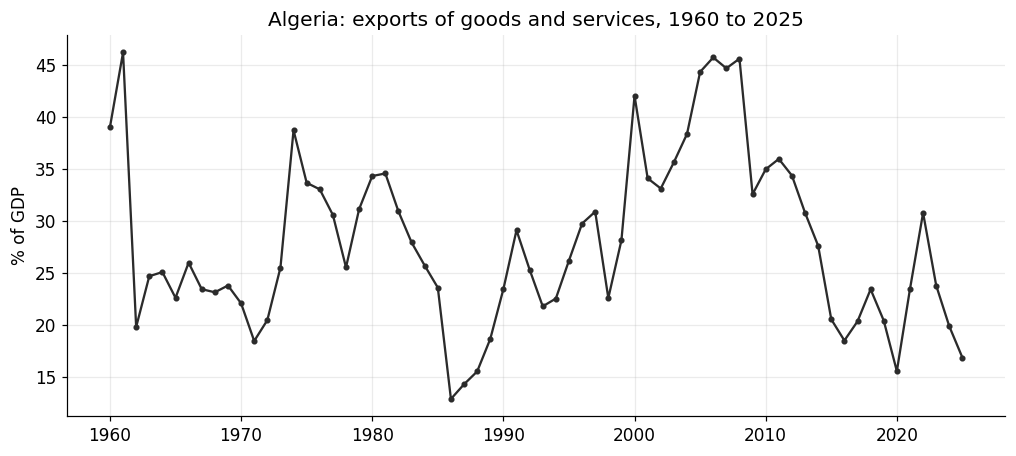

In [4]:
fig, ax = plt.subplots()
ax.plot(y.index.year, y.values, color=OBS, lw=1.5, marker="o", ms=3)
ax.set_title("Algeria: exports of goods and services, 1960 to 2025")
ax.set_ylabel("% of GDP")
plt.show()

## 3. Moving average

Two moving averages below, of order 3 and 9, written 3-MA and 9-MA. Each one replaces a year with the average of a window of years, which smooths out the year to year noise and makes the broader movement easier to see.

The 9-MA is smoother than the 3-MA, but it lags further behind and loses more years. That trade-off is what the window size buys you.

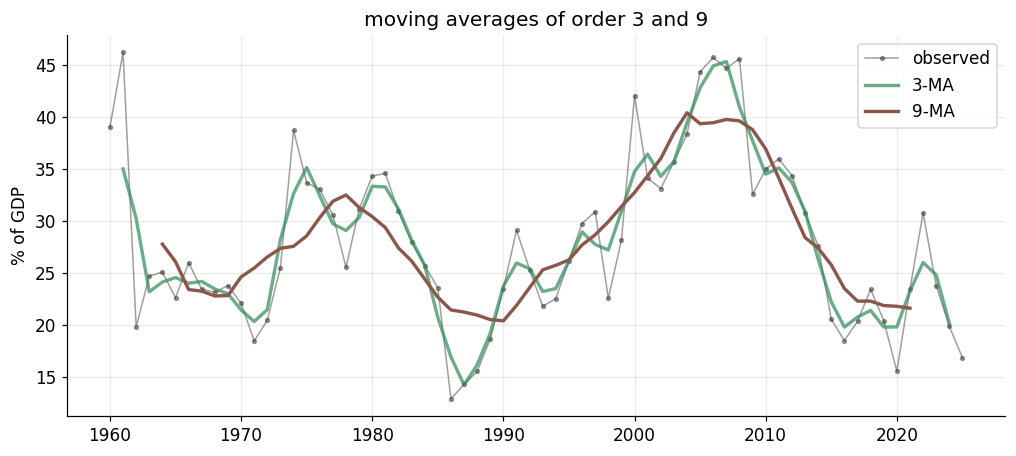

In [16]:
# center=False averages each year with the ones before it
ma3 = y.rolling(window=3, center=True).mean()
ma9 = y.rolling(window=9, center=True).mean()

fig, ax = plt.subplots()
ax.plot(y.index.year, y.values, color=OBS, lw=1, alpha=0.45, marker="o", ms=2.5, label="observed")
ax.plot(ma3.index.year, ma3.values, color=MA3, lw=2.2, alpha = 0.70, label="3-MA")
ax.plot(ma9.index.year, ma9.values, color=MA9, lw=2.2, label="9-MA")
ax.set_title("moving averages of order 3 and 9")
ax.set_ylabel("% of GDP")
ax.legend()
plt.show()

## 4. Train / test split

We train on **1960 to 2017** and test on **2018 to 2025**.

We should acknowledge that eight test years is a small sample, and it includes the 2020 pandemic drop and the 2022 energy price spike.

In [6]:
train, test = y[:"2017"], y["2018":]
H = len(test)

print(f"train: {train.index[0]} to {train.index[-1]}, {len(train)} years")
print(f"test : {test.index[0]} to {test.index[-1]}, {H} years")

train: 1960 to 2017, 58 years
test : 2018 to 2025, 8 years


## 5. Basic forecasting methods demo

A quick refresher. $\hat{y}_{T+h|T}$ is the forecast $h$ years ahead, made with data up to year $T$.

- **Mean**: $\hat{y}_{T+h|T} = \bar{y}$. Every past year counts equally.
- **Naive**: $\hat{y}_{T+h|T} = y_T$. Only the latest year counts.
- **SES**: $\hat{y}_{T+h|T} = \alpha y_T + \alpha(1 - \alpha)y_{T-1} + \alpha(1-\alpha)^2 y_{T-2}$..., so it is an average of all data points with different assinged weights and $\alpha$ decides how hard. Recent years count more and older years fade.

Estimation picks the $\alpha$ that minimises the squared one step errors.

In [7]:
mean_forecast  = train.mean()
naive_forecast = train.iloc[-1]

ses_fit = SimpleExpSmoothing(train, initialization_method="heuristic").fit()
alpha = ses_fit.params["smoothing_level"]

forecasts = {
    "Mean":  pd.Series(mean_forecast,  index=test.index),
    "Naive": pd.Series(naive_forecast, index=test.index),
    "SES":   ses_fit.forecast(H),
}

# what each method would have predicted for every training year
fitted = {
    "Mean":  pd.Series(mean_forecast, index=train.index),
    "Naive": train.shift(1),
    "SES":   ses_fit.fittedvalues,
}
colours = {"Mean": MEAN, "Naive": NAIVE, "SES": SES}

print(f"mean forecast  : {mean_forecast:.3f}")
print(f"naive forecast : {naive_forecast:.3f}")
print(f"SES alpha      : {alpha:.3f}")

# all three forecasts are flat, so the 2018 value is the one repeated through to 2025
pd.DataFrame({"forecast for 2018": {n: fc.iloc[0] for n, fc in forecasts.items()}}).round(3)

mean forecast  : 28.807
naive forecast : 20.334
SES alpha      : 0.817


,forecast for 2018
Mean,28.807
Naive,20.334
SES,20.112


We can see here that SES model assigned a high $\alpha$ of 0.82, leading us to forecast something similar to Naive. This shows that past historical patterns matter less to this dataset and the most recent observation is a better guide than the long run average.

## 6. Visualisation of one step ahead forecasts for each methods

Each coloured line shows the method's **fitted values**. For each year, roughly the forecast it would have made from the years before. Strictly, these are not true forecasts, because parameters such as the mean or $\alpha$ were estimated using all the training years.

- **Mean**: a flat line at the average.
- **Naive**: the series shifted one year to the right.
- **SES**: follows the series, slightly smoothed and lagged.

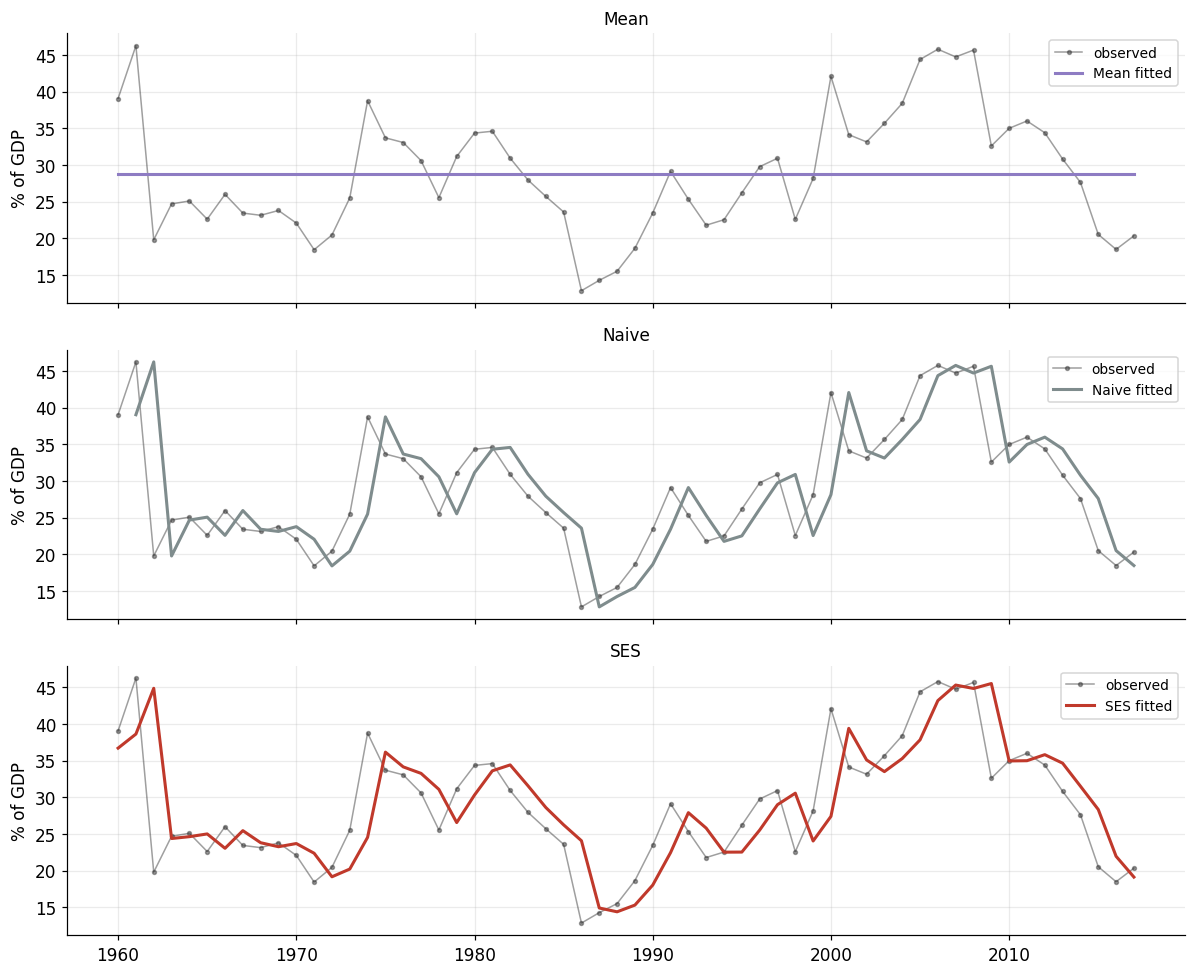

In [8]:
yrs = train.index.year

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, sharey=True)
for ax, (name, values) in zip(axes, fitted.items()):
    ax.plot(yrs, train.values, color=OBS, lw=1, alpha=0.45, marker="o", ms=2.5, label="observed")
    ax.plot(yrs, values.values, color=colours[name], lw=2, label=f"{name} fitted")
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("% of GDP")
    ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## 7. All three forecasts together

Naive and SES sit almost on top of each other, so we express Naive as the thick grey line running underneath the red SES dashes.

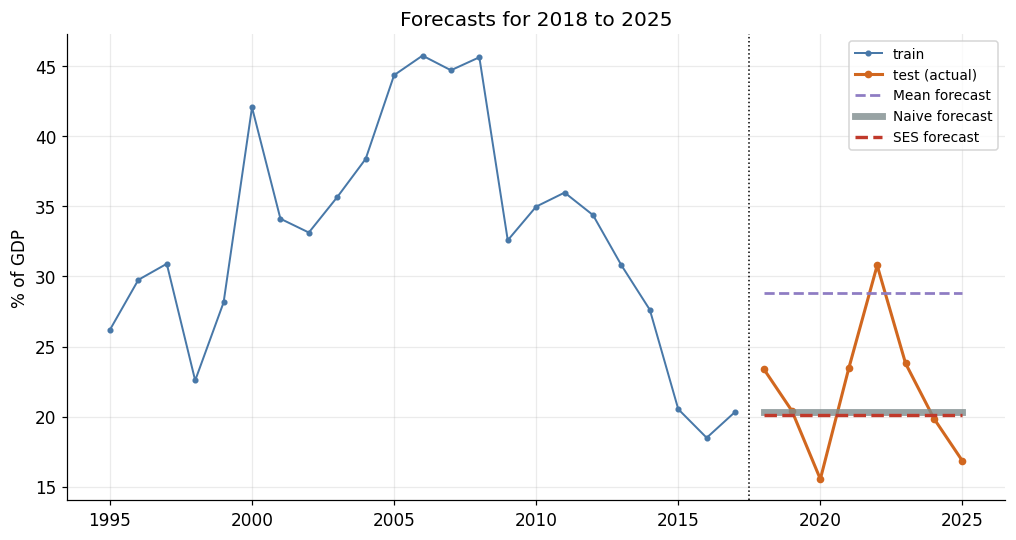

In [9]:
recent = train["1995":]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(recent.index.year, recent.values, color=TRAIN, lw=1.3, marker="o", ms=3, label="train")
ax.plot(test.index.year, test.values, color=TEST, lw=2, marker="o", ms=4, label="test (actual)")
styles = {"Mean": dict(ls="--", lw=1.8), "Naive": dict(ls="-", lw=4.5, alpha=0.8), "SES": dict(ls="--", lw=2.2)}
for name, fc in forecasts.items():
    ax.plot(fc.index.year, fc.values, color=colours[name], **styles[name],
            label=f"{name} forecast")
ax.axvline(2017.5, color="k", ls=":", lw=1)
ax.set_title("Forecasts for 2018 to 2025")
ax.set_ylabel("% of GDP")
ax.legend(fontsize=9)
plt.show()

**Intrpretations**
1. The mean overshoots almost every test year. 
2. Naive gives close predictions for 2019 and 2024, and is nearer than the mean in every other year except 2020 pandemic dip and 2022 oil price spike, and SES gives almost the same forecast as naive.

In conclusion, for this dataset older history adds very little and the most recent observation serves as a better guide to next year. That is why SES estimates a high $\alpha$ (0.82) and ends up forecasting almost the same as the naive method.

# APPENDIX

## 8. Evaluation: MASE and AICc

Recap of MASE and AICc.

**MASE** asks how good the forecasts were for the test years. Each test error is divided by the average error the naive method made one step ahead on the training years:

$$q_j = \frac{e_j}{\frac{1}{T-1}\sum_{t=2}^{T}|y_t - y_{t-1}|}, \qquad \text{MASE} = \text{mean}(|q_j|)$$

To put it simply, MASE is a fraction:

- the **numerator** is the model's absolute error on the test years
- the **denominator** is the average error the naive method would have made one step ahead there

Every model is divided by the same denominator, so the scores are comparable. Below 1 means model performed better than naive errors from training data, above 1 means it did worse.

**AICc** asks how well the model fits the training years, after a penalty for every quantity it estimated:

$$\text{AIC} = -2\log(L) + 2k, \qquad \text{AIC}_c = \text{AIC} + \frac{2k(k+1)}{T-k-1}$$

$L$ is the likelihood and $k$ counts everything estimated, including the residual variance. Naive estimates nothing at all, since its forecast is just the last observation, so $k = 1$, the variance on its own. The mean method is counted the same way, $k = 1$. SES also estimates $\alpha$, so $k = 2$. All three are scored on 1961 to 2017, because naive has no forecast for 1960. Lower is better, but only the differences between models mean anything, and only when the models are fitted to the same data, as they are here. 

In [10]:
def mase(actual, forecast, train):
    scale = np.mean(np.abs(np.diff(train.values)))
    return np.mean(np.abs(actual.values - forecast.values)) / scale

def aicc(resid, k):
    T = len(resid)
    # Gaussian log likelihood, with the variance estimated as the mean squared residual
    loglik = -T / 2 * (np.log(2 * np.pi * np.mean(resid ** 2)) + 1)
    aic = -2 * loglik + 2 * k
    return aic + 2 * k * (k + 1) / (T - k - 1)

k_params = {"Mean": 1, "Naive": 1, "SES": 2}

results = pd.DataFrame({
    "k":    k_params,
    "AICc": {n: aicc((train - fitted[n])["1961":].values, k_params[n]) for n in fitted},
    "MASE": {n: mase(test, forecasts[n], train) for n in forecasts},
})
results["AICc minus lowest"] = results["AICc"] - results["AICc"].min()

results.round(3)

,k,AICc,MASE,AICc minus lowest
Mean,1,403.086,1.808,34.670
Naive,1,368.416,0.868,0.000
SES,2,369.223,0.881,0.807


## 9. Which seems better?

**Naive and SES are close to a tie, and both are clearly better than the mean.**

- **The mean is the worst on both measures**: MASE 1.81, and an AICc roughly 34 to 35 points above the other two. Averaging all 58 years pulls in the 2000s, when exports averaged about 40% of GDP, well above where Algeria has been since.
- **Naive edges SES on both, but only just**: MASE 0.87 against 0.88, and an AICc lower by less than one point. With $\alpha = 0.82$, SES already puts a lot of weight on the last observation, making it forecast a similar value as Naive. Estimating $\alpha$ improved the fit on the training years slightly, but not by enough to cover the AICc penalty for its extra parameter.

Naive edging SES is not a reason to reach for naive in general. The mean and naive methods exist as **benchmarks** for more complex models to beat. The claim we make here is as such: 

> On these eight test years, SES did not earn its extra parameter. Two of those years were shocks, so the gap is thin evidence either way.

## 10. AR, MA and ARMA models

SES always gives a flat forecast as it is a result of weighted average. For AR, MA and ARMA models, we consider the short terms fluctuations so that their forecast path can move.

- **AR(p)**, autoregressive. The series regressed on its own recent values:

$$y_t = c + \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t$$

- **MA(q)**, moving average model. The series regressed on its own recent forecast errors:

$$y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}$$

- **ARMA(p,q)** uses both parts at once.


**Requirement.** MA and ARMA assume the series is stationary, which roughly means no trend and no wandering level. We are using a series that is already tested to be stationary but stationarity does not always hold and may need differencing for other types of time series data.

In [11]:
from statsmodels.tsa.arima.model import ARIMA

AR1_COL, MA1_COL, ARMA1_COL, AR2_COL, MA2_COL, ARMA2_COL = "#0d7d7d", "#b8860b", "#6a3d9a", "#16a085", "#e74c3c", "#9b59b6"

arma_models = {
    "AR(1)":     ARIMA(train, order=(1, 0, 0), trend="c").fit(),
    "MA(1)":     ARIMA(train, order=(0, 0, 1), trend="c").fit(),
    "ARMA(1,1)": ARIMA(train, order=(1, 0, 1), trend="c").fit(),
    "AR(2)":     ARIMA(train, order=(2, 0, 0), trend="c").fit(),
    "MA(2)":     ARIMA(train, order=(0, 0, 2), trend="c").fit(),
    "ARMA(2,2)": ARIMA(train, order=(2, 0, 2), trend="c").fit(),
}
arma_cols = {
    "AR(1)": AR1_COL, "MA(1)": MA1_COL, "ARMA(1,1)": ARMA1_COL,
    "AR(2)": AR2_COL, "MA(2)": MA2_COL, "ARMA(2,2)": ARMA2_COL,
}
arma_fc = {n: pd.Series(np.asarray(r.forecast(H)), index=test.index) for n, r in arma_models.items()}

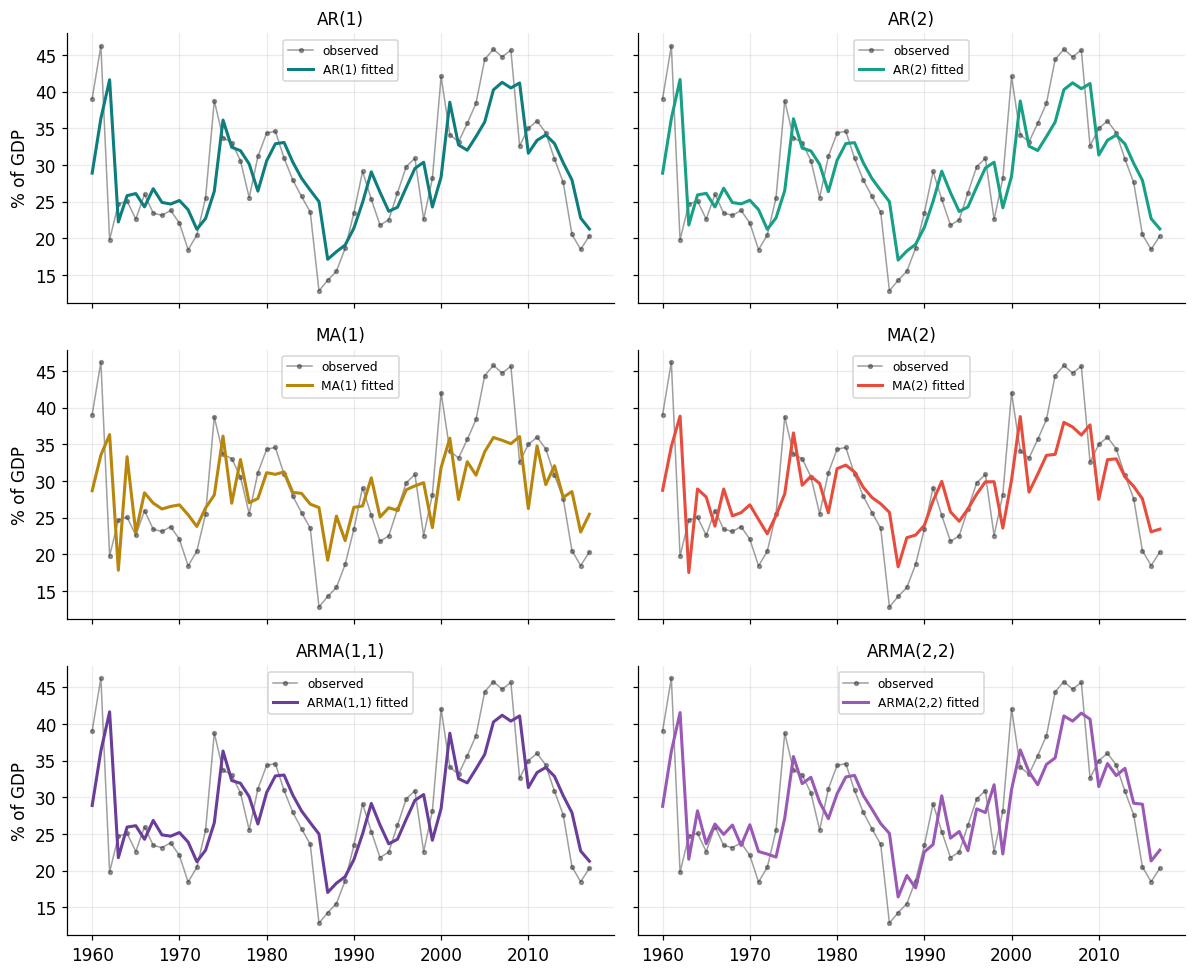

In [12]:
layout = [("AR(1)", "AR(2)"), ("MA(1)", "MA(2)"), ("ARMA(1,1)", "ARMA(2,2)")]

fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True, sharey=True)
for row_axes, row_names in zip(axes, layout):
    for ax, name in zip(row_axes, row_names):
        res = arma_models[name]
        ax.plot(train.index.year, train.values, color=OBS, lw=1, alpha=0.45, marker="o", ms=2.5, label="observed")
        ax.plot(train.index.year, np.asarray(res.fittedvalues), color=arma_cols[name], lw=2, label=f"{name} fitted")
        ax.set_title(name, fontsize=11)
        ax.legend(fontsize=8, loc="upper center")
    row_axes[0].set_ylabel("% of GDP")
plt.tight_layout()
plt.show()

AR(1) and AR(2) plots look almost the same. This shows that the optimisation algorithm assigned a very low value for the second AR term as it doesn't help improve the model fit. This is also shown later on the table for each AICc metrics.

## 11. Comparing the forecasts with SES

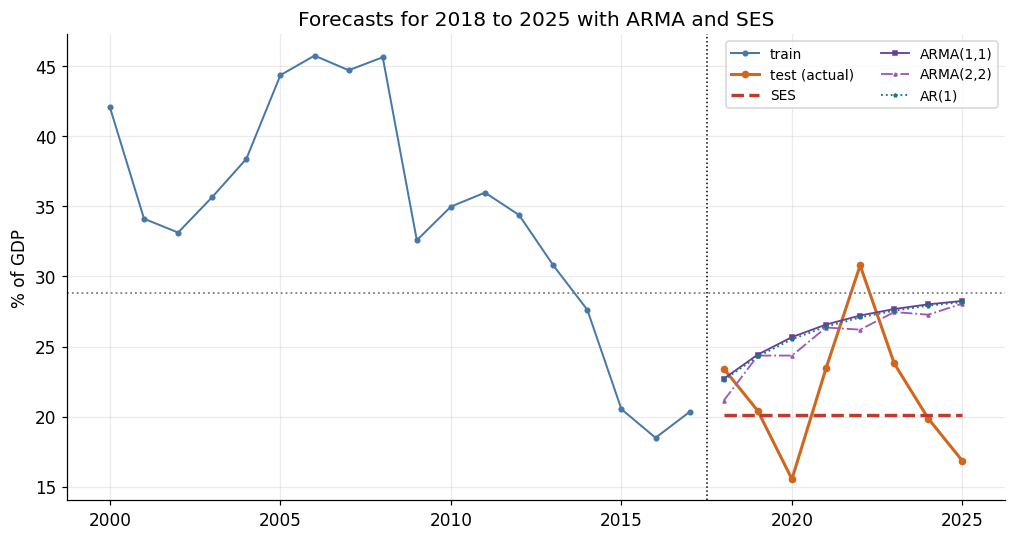

In [13]:
recent = train["2000":]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(recent.index.year, recent.values, color=TRAIN, lw=1.3, marker="o", ms=3, label="train")
ax.plot(test.index.year, test.values, color=TEST, lw=2, marker="o", ms=4, label="test (actual)")
ax.plot(test.index.year, forecasts["SES"].values, color=SES, lw=2.2, ls="--", label="SES")

styles = {"ARMA(1,1)": dict(ls="-", marker="s"), "ARMA(2,2)": dict(ls="-.", marker="^"), "AR(1)": dict(ls=":", marker="p")}
for name, style in styles.items():
    ax.plot(test.index.year, arma_fc[name].values, color=arma_cols[name], lw=1.2, ms=2, label=name, **style)

ax.axhline(train.mean(), color="0.5", ls=":", lw=1.2)
ax.axvline(2017.5, color="k", ls=":", lw=1)
ax.set_title("Forecasts for 2018 to 2025 with ARMA and SES")
ax.set_ylabel("% of GDP")
ax.legend(fontsize=9, ncol=2)
plt.show()

Three different behaviours:

- **SES** is flat at 20.1 for all eight years. Its level stops updating the moment the data runs out.
- **ARMA(1,1)** starts at 22.7 and climbs smoothly towards the long-run mean of 28.9. Each forecast feeds into the next, so the path keeps moving.
- **ARMA(2,2)** starts at 21.1 and climbs in steps. It heads for much the same long-run mean, just less smoothly.

In [14]:
arma_scores = pd.DataFrame({
    "k":    {n: len(r.params) for n, r in arma_models.items()},
    "AICc": {n: aicc(np.asarray(r.resid), len(r.params)) for n, r in arma_models.items()},
})
arma_scores["AICc minus lowest"] = arma_scores["AICc"] - arma_scores["AICc"].min()
print("within the ARMA family only (AICc cannot cross model classes):")
print(arma_scores.round(3).to_string())

comparison = pd.DataFrame({"MASE": {
    **results["MASE"].to_dict(),
    **{n: mase(test, fc, train) for n, fc in arma_fc.items()},
}})
comparison.sort_values("MASE").round(3)

within the ARMA family only (AICc cannot cross model classes):
           k     AICc  AICc minus lowest
AR(1)      3  372.813              0.000
MA(1)      3  384.023             11.210
ARMA(1,1)  4  375.109              2.296
AR(2)      4  375.110              2.298
MA(2)      4  381.714              8.902
ARMA(2,2)  6  378.710              5.897


,MASE
Naive,0.868
SES,0.881
AR(1),1.334
"ARMA(2,2)",1.344
AR(2),1.348
"ARMA(1,1)",1.350
MA(2),1.666
MA(1),1.678
Mean,1.808


## 12. What ARMA adds, and what it costs

- **Within the ARMA family, AR(1) still fits best**, with an AICc of 372.8. The larger models do not earn their extra parameters: AR(2) and ARMA(1,1) both score 375.1. ARMA(2,2) scores 378.7, and the MA models trail at 381.7 for MA(2) and 384.0 for MA(1).
- **On this test window the ARMA forecasts were less accurate**: MASE 1.33 for AR(1), the best of the six, against 0.88 for SES and 0.87 for naive, with the other five between 1.34 and 1.68.